## Comparación entre la conductividad en materiales comunes e inteligentes

## Simulación 1D con conductividad constante

Se implementa un modelo 1D de conducción térmica mediante un esquema explícito de difusión.

La pared se discretiza en N nodos y se fija una temperatura en el extremo interior.
La conductividad térmica se considera constante en todo el material.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def temperatura_k_constante(T0,Tf):
    N = 50
    L = 0.1
    k = 0.5
    dx = L/(N-1)
    factor = 1e-6   # controla velocidad del cambio

    T = [T0]*N #Temperatura calor incidente
    T[-1] = Tf  #Temperatura habitacion interior

    for _ in range(1000):

        T_new = T.copy()

        for i in range(1, N-1):
            T_new[i] = T[i] + factor*k*(T[i+1] - 2*T[i] + T[i-1]) / dx**2
        T_new[-1] = Tf
        T = T_new
    return T[-2]
temperatura_k_constante(300,280)

281.02892844989407

In [34]:
def temperatura_k_constante_lista(T0,Tf):
    N = 50
    L = 0.1
    k = 0.5
    dx = L/(N-1)
    factor = factor = 1e-6   # controla velocidad del cambio

    T = [T0]*N #Temperatura calor incidente
    T[-1] = Tf  #Temperatura habitacion interior

    for _ in range(1000):

        T_new = T.copy()

        for i in range(1, N-1):
            T_new[i] = T[i] + factor*k*(T[i+1] - 2*T[i] + T[i-1]) / dx**2
        T_new[-1] = Tf
        T = T_new
    return T
temperatura_k_constante_lista(313,280)


[313,
 312.97683838869193,
 312.9528130403104,
 312.9270432035294,
 312.89861420888786,
 312.866560793011,
 312.8298507830814,
 312.78736929452066,
 312.7379036211176,
 312.68012902732397,
 312.6125956856088,
 312.5337170358338,
 312.4417598765914,
 312.3348365281541,
 312.2108994308332,
 312.067738558813,
 311.9029820356093,
 311.7141003310416,
 311.49841439908636,
 311.2531080795972,
 310.9752450335168,
 310.661790410281,
 310.30963735770797,
 309.9156383795815,
 309.47664142597426,
 308.98953046852046,
 308.4512701705602,
 307.8589541143136,
 307.2098558986595,
 306.5014822768878,
 305.73162736954527,
 304.8984268689556,
 304.00041105485707,
 303.03655537025065,
 302.00632726779867,
 300.9097280339493,
 299.74732833329364,
 298.5202962911424,
 297.2304170481422,
 295.88010287559314,
 294.4723931310623,
 293.01094355642476,
 291.50000466867556,
 289.94438926053107,
 288.3494293047489,
 286.7209228342763,
 285.06507164046377,
 283.38841088433196,
 281.6977319423252,
 280]

## Perfil de temperatura en régimen transitorio

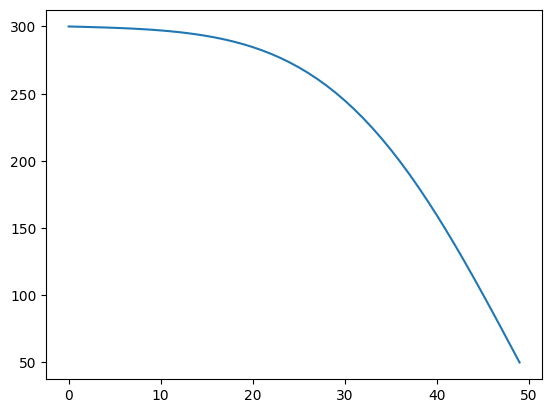

In [35]:
def graficar_k_constante_lista(T0,Tf):   
    T = temperatura_k_constante_lista(T0,Tf)
    plt.plot(T)
    plt.show()
graficar_k_constante_lista(300,50)

La gráfica muestra la distribución espacial de temperatura a lo largo de la pared.

El perfil evoluciona progresivamente hacia una forma aproximadamente lineal, característica del estado estacionario en materiales con conductividad constante.


## Relación entre temperatura incidente y respuesta interior (k constante)


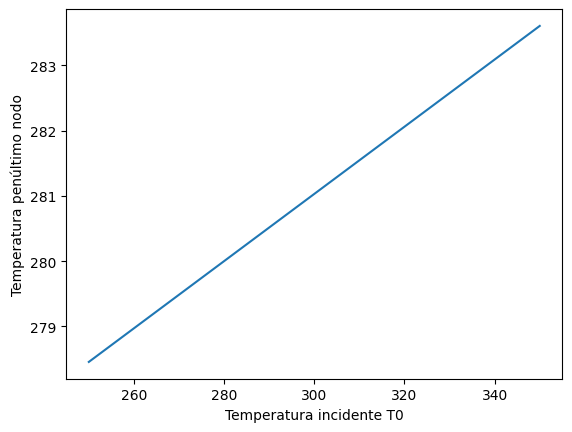

In [36]:
lista_temperaturas = []

for T0 in range(250, 351):   # de 250 a 350
    valor = temperatura_k_constante(T0, 280)
    lista_temperaturas.append(valor)

plt.plot(range(250, 351), lista_temperaturas)
plt.xlabel("Temperatura incidente T0")
plt.ylabel("Temperatura penúltimo nodo")
plt.show()

La relación entre la temperatura exterior (T₀) y la temperatura cercana al interior es prácticamente lineal.

Esto confirma el comportamiento esperado de un material convencional con conductividad constante, donde la transmisión de calor es proporcional al gradiente térmico y no existe adaptación frente a cambios térmicos.

## Simulación con conductividad térmica dependiente de la temperatura


Se modifica el modelo anterior introduciendo una conductividad térmica local k(T).

El material reduce su conductividad a altas temperaturas y la aumenta a bajas temperaturas, simulando un comportamiento adaptativo.


In [37]:
def temperatura_k_inteligente(T0,Tf):
    N = 50
    L = 0.1
    dx = L/(N-1)
    factor = 1e-6   # controla velocidad del cambio

    T = [T0]*N #Temperatura calor incidente
    T[-1] = Tf  #Temperatura habitacion interior

    for _ in range(1000):

        T_new = T.copy()

        for i in range(1, N-1):
            k_local = max(0.05, 0.5 - 0.02*(T[i] - Tf))
            T_new[i] = T[i] + factor*k_local*(T[i+1] - 2*T[i] + T[i-1]) / dx**2
        T_new[-1] = Tf
        T = T_new
    return T[-2]
print(temperatura_k_inteligente(250,300))
print(temperatura_k_inteligente(300,250))

298.245693562947
257.45310042824565


In [38]:
def temperatura_k_inteligente_lista(T0,Tf):
    N = 50
    L = 0.1
    dx = L/(N-1)
    factor = 1e-6   # controla velocidad del cambio

    T = [T0]*N #Temperatura calor incidente
    T[-1] = Tf  #Temperatura habitacion interior

    for _ in range(1000):

        T_new = T.copy()

        for i in range(1, N-1):
            k_local = max(0.05, 0.5 - 0.02*(T[i] - Tf))
            T_new[i] = T[i] + factor*k_local*(T[i+1] - 2*T[i] + T[i-1]) / dx**2
        T_new[-1] = Tf
        T = T_new
    return T

## Perfil de temperatura con conductividad térmica dependiente de la temperatura

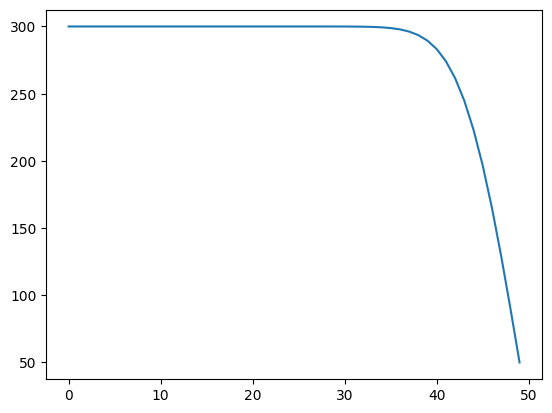

In [39]:
def graficar_k_inteligente_lista(T0,Tf):   
    T = temperatura_k_inteligente_lista(T0,Tf)
    plt.plot(T)
    plt.show()
graficar_k_inteligente_lista(300,50)

La distribución obtenida no es lineal, a diferencia del caso con conductividad constante.

En la zona caliente, la conductividad disminuye, lo que reduce la transmisión térmica y genera un perfil más plano.
En la zona fría, la conductividad aumenta, concentrando el gradiente térmico cerca del extremo interior.

Este comportamiento confirma la capacidad del material para modificar pasivamente la transmisión de calor en función de las condiciones térmicas.


## Relación entre temperatura incidente y respuesta interior (material inteligente)


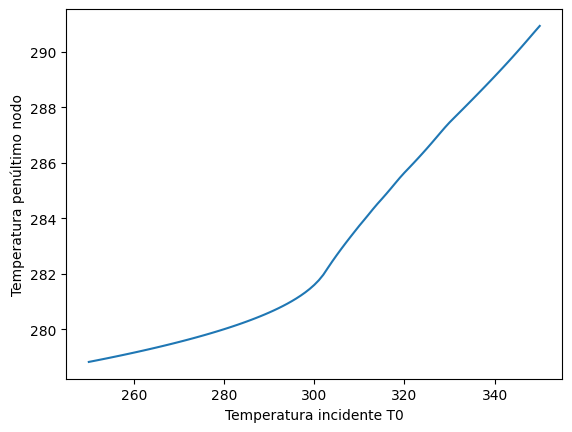

In [40]:
lista_temperaturas = []

for T0 in range(250, 351):   # de 250 a 350
    valor = temperatura_k_inteligente(T0, 280)
    lista_temperaturas.append(valor)

plt.plot(range(250, 351), lista_temperaturas)
plt.xlabel("Temperatura incidente T0")
plt.ylabel("Temperatura penúltimo nodo")
plt.show()


A diferencia del material con conductividad constante, la relación ya no es estrictamente lineal.

La variación local de la conductividad térmica introduce un comportamiento no lineal, evidenciando una respuesta adaptativa frente a cambios en la temperatura exterior.

Este resultado confirma que el material modifica la transmisión de calor en función de las condiciones térmicas, actuando como sistema pasivo de regulación.

In [41]:
def mejora(T0,Tf):
    T_int = temperatura_k_inteligente(T0,Tf)
    T_const = temperatura_k_constante(T0,Tf)

    #print(f'La temperatura del material inteligente es {T_int:.2f} K')
    #print(f'La temperatura del material común es {T_const:.2f} K')
    
    porcentaje_mejora = 100*(T_int - T_const)/T_const
    #print(f'El porcentaje de mejora es de {porcentaje_mejora}')
    return porcentaje_mejora

    
mejora(350,300)


1.6130951057808323

## Comparación cuantitativa entre material convencional e inteligente

Para evaluar el impacto real del comportamiento adaptativo, se calcula la diferencia entre la temperatura obtenida con conductividad constante y la obtenida con conductividad dependiente de la temperatura.

Este análisis permite cuantificar la variación introducida por el material inteligente y evaluar su efecto en términos relativos.


## Conclusión

Las simulaciones realizadas muestran que un material con conductividad térmica constante presenta un comportamiento lineal y predecible, donde la transmisión de calor es proporcional al gradiente térmico impuesto.

En contraste, al introducir una conductividad dependiente de la temperatura, el sistema deja de comportarse de forma estrictamente lineal. La variación local de k(T) modifica la distribución espacial de temperatura y la sensibilidad frente a cambios térmicos exteriores.

El material propuesto demuestra un comportamiento adaptativo: reduce la transmisión térmica cuando se expone a altas temperaturas y favorece la redistribución cuando se encuentra en condiciones más frías. 

Estos resultados respaldan el potencial de los materiales con propiedades térmicas variables como herramienta de regulación pasiva en aplicaciones de construcción y eficiencia energética.


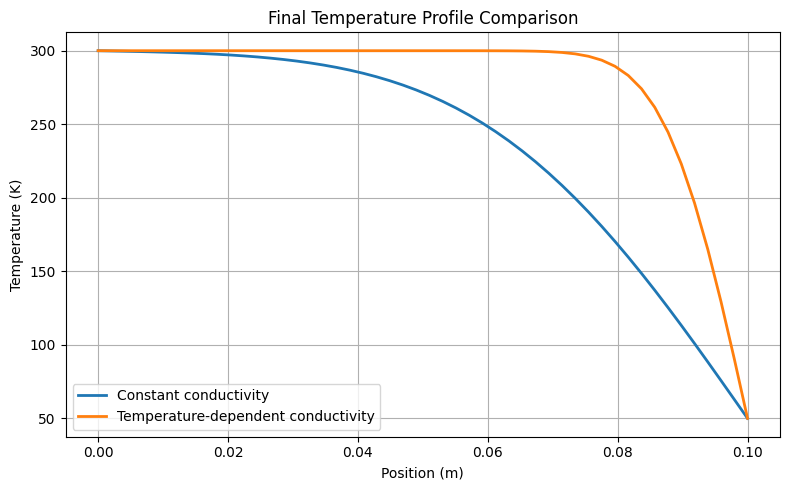

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
T0 = 300   # temperatura izquierda
Tf = 50    # temperatura derecha
N = 50
L = 0.1
x = np.linspace(0, L, N)

# Obtener resultados
T_constante = temperatura_k_constante_lista(T0, Tf)
T_inteligente = temperatura_k_inteligente_lista(T0, Tf)

# Crear figura
plt.figure(figsize=(8,5))

plt.plot(x, T_constante, label="Constant conductivity", linewidth=2)
plt.plot(x, T_inteligente, label="Temperature-dependent conductivity", linewidth=2)

plt.xlabel("Position (m)")
plt.ylabel("Temperature (K)")
plt.title("Final Temperature Profile Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()

# Guardar imagen para Overleaf
plt.savefig("profile_comparison.png", dpi=300)

plt.show()


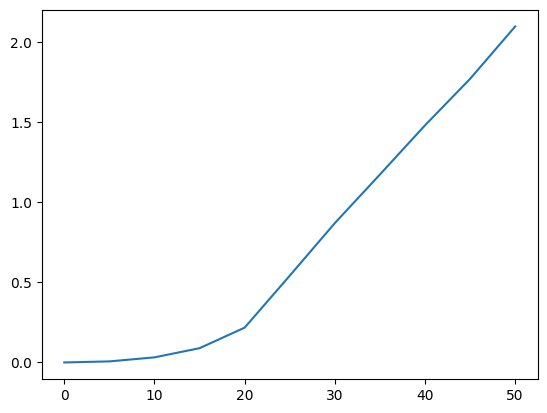

In [43]:

porcentajes_mejora = []
valores = [0,5,10,15,20,25,30,35,40,45,50]
T0 = 280
for i in valores:
    Tf = 280 - i
    porcentajes_mejora.append(mejora(T0,Tf))
plt.plot(valores, porcentajes_mejora)

In [44]:
T0 = 280
Tf = 250

Tint = temperatura_k_inteligente(T0, Tf)
Tconst = temperatura_k_constante(T0, Tf)

print("Tint:", Tint)
print("Tconst:", Tconst)


Tint: 253.7326536063197
Tconst: 251.54339267484107
